In [ ]:
# Step 1 Upload file from local system
from google.colab import files
uploaded=files.upload()

# get uploaded file name automatically
file_name=list(uploaded.keys())[0]

Saving svm_farming_datasets (1).xlsx to svm_farming_datasets (1).xlsx


In [ ]:
#2 import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

# step 3 Load dataset
df=pd.read_excel("svm_farming_datasets (1).xlsx")

print("Dataset loadeed successfully\n")
print(df.head())


Dataset loadeed successfully

  Sample ID  Soil Nitrogen (mg/kg)  Avg Rainfall (mm)  Class Label    Class
0      W001                  70.83             602.05            1  Healthy
1      W002                  75.15             556.55            1  Healthy
2      W003                  92.58             698.62            1  Healthy
3      W004                  84.47             608.76            1  Healthy
4      W005                  66.91             723.59            1  Healthy


In [ ]:
# STep 4 Clean column NAmes
df.columns=df.columns.str.strip()

# Rename soil nitrogen and rainfall columns
df.rename(columns={
    "Soil Nitrogen (mg/kg)":"Soil_Nitrogen",
    "Avg Rainfall (mm)": "Rainfall" # Corrected 'rainfall' to 'Rainfall'
}, inplace=True)
# Drop the sample id column as its not required

if "Sample ID" in df.columns:
  df.drop(columns=["Sample ID"], inplace=True)

# Ensure the class coilumn contain numerical labels for the model
if "Class Label" in df.columns and "Class" in df.columns:
  df.rename(columns={
      "Class Label":"Class"
  },inplace=True)

In [ ]:
# Step 5 Features and label
X=df[["Soil_Nitrogen","Rainfall"]]
y=df["Class"]
# # Step 6 Train TEst split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

# 7 Function Train+Evaluate + plot

def train_and_plot(C, subpolt_index):
 model=svm.SVC(kernel="linear",C=C)
 model.fit(X_train,y_train)

 # predictions
 y_pred=model.predict(X_test)

 # Evaluation
 print(f"\n==== Results for C={C} ====")
 print("Accuracy:", accuracy_score(y_test,y_pred))
 print("Confusion Matrix:\n",confusion_matrix(y_test,y_pred))
 print("Classification Report:\n",classification_report(y_test,y_pred))
 # Plotting

 plt.subplot(1,3,subplot_index)
 for label,color in zip([1,-1],["green","red"]):
  subset=df[df["Class"]==label]
  plt.scatter(subset["Soil_Nitrogen"],
              subset["Rainfall"],
              c=color,
              label=("Healthy" if label==1 else "Stressed"))
  # Decision boundry
  ax=plt.gca()
  xlim=ax.get_xlim()
  ylim=ax.get_ylim()

  xx=np.linspace(xlim[0],xlim[1],30)
  yy=np.linspace(ylim[0],ylim[1],30)
  YY,XX=np.meshgrid(yy,xx)

  xy=np.vstack([XX.ravel(),YY.ravel()]).T
  Z=model.decision_function(xy).reshape(XX.shape)

  # boundry
  ax.contour(XX,YY,Z,levels=[0],linewidth=2)

  # Margins
  ax.contour(XX,YY,Z,levels=[-1,1],linestyles=["--","--"])

  # Support vectors
  ax.scatter(model.support_vectors_[:,0],
             model.support_vectors_[:,1],
             s=100,facecolors="none",
             edgecolors="black",
             label="Support vectors")
  plt.xlabel("Soil Nitrogen")
  plt.ylabel("rainfall")
  plt.title(f"C={C}")
  plt.legend()


Dataset loadeed successfully

  Sample ID  Soil Nitrogen (mg/kg)  Avg Rainfall (mm)  Class Label    Class
0      W001                  70.83             602.05            1  Healthy
1      W002                  75.15             556.55            1  Healthy
2      W003                  92.58             698.62            1  Healthy
3      W004                  84.47             608.76            1  Healthy
4      W005                  66.91             723.59            1  Healthy

==== Results for C=0.01 ====
Accuracy: 1.0
Confusion Matrix:
 [[ 9  0]
 [ 0 12]]
Classification Report:
               precision    recall  f1-score   support

          -1       1.00      1.00      1.00         9
           1       1.00      1.00      1.00        12

    accuracy                           1.00        21
   macro avg       1.00      1.00      1.00        21
weighted avg       1.00      1.00      1.00        21


==== Results for C=1 ====
Accuracy: 1.0
Confusion Matrix:
 [[ 9  0]
 [ 0 12]]
Cl

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/tmp/ipykernel_2144/907221048.py:82: UserWarning: The following kwargs were not used by contour: 'linewidth'
  ax.contour(XX,YY,Z,levels=[0],linewidth=2)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/tmp/ipykernel_2144/907221048.py:82: UserWarning: The following kwargs were not used by contour: 'linewidth'
  ax.contour(XX,YY,Z,levels=[0],linewidth=2)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/tmp/ipykernel_2144/907221048.py:82: UserWarning: The following kwargs were not used by contour: 'linewidth'
  ax.contour(XX,YY,Z,levels=[0],linewidth=2)
/

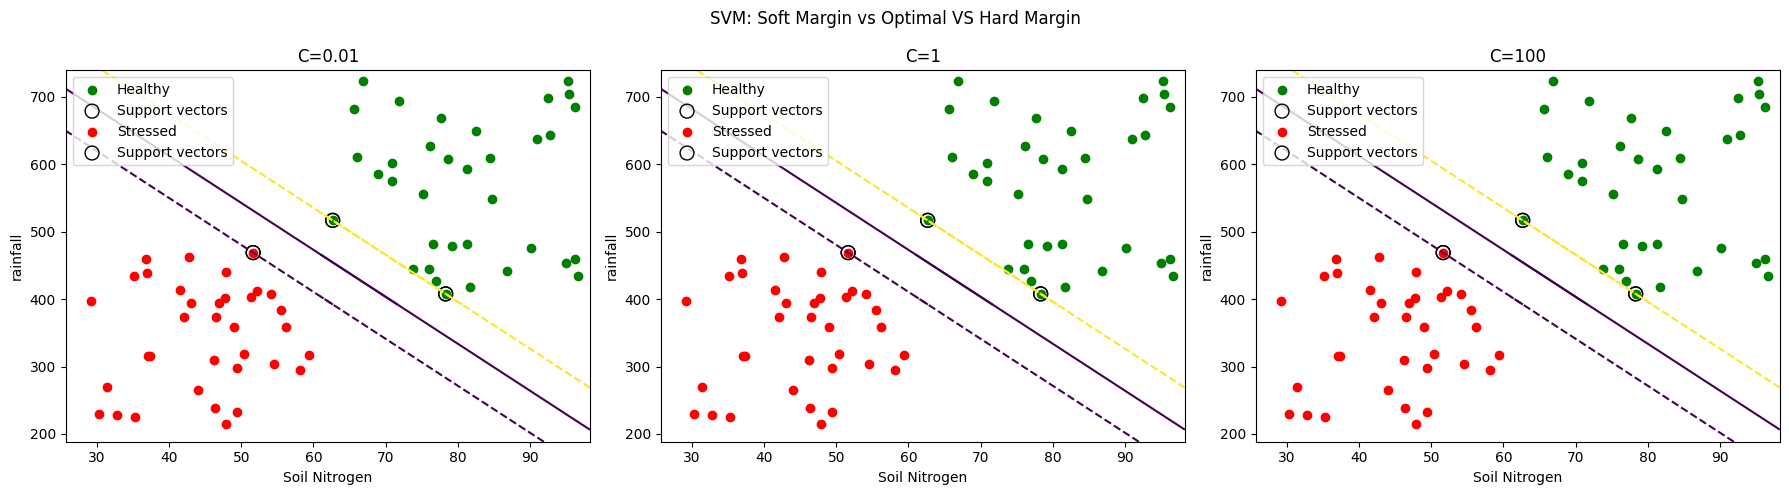

In [ ]:
#2 import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

# step 3 Load dataset
df=pd.read_excel("svm_farming_datasets (1).xlsx")

print("Dataset loadeed successfully\n")
print(df.head())

# STep 4 Clean column NAmes
df.columns=df.columns.str.strip()

# Rename soil nitrogen and rainfall columns
df.rename(columns={
    "Soil Nitrogen (mg/kg)":"Soil_Nitrogen",
    "Avg Rainfall (mm)": "Rainfall"
}, inplace=True)

# Drop the sample id column as its not required
if "Sample ID" in df.columns:
  df.drop(columns=["Sample ID"], inplace=True)

# Handle Class columns to ensure only one 'Class' column with numerical labels exists
if "Class Label" in df.columns and "Class" in df.columns:
    # Keep 'Class Label' (numerical) and rename it to 'Class', then drop the old 'Class' (string)
    df["Class_temp"] = df["Class Label"] # Create a temporary column for numerical class
    df.drop(columns=["Class Label", "Class"], inplace=True) # Drop both original Class columns
    df.rename(columns={"Class_temp": "Class"}, inplace=True) # Rename temp to final 'Class'
elif "Class Label" in df.columns:
    # If only "Class Label" exists, rename it to "Class"
    df.rename(columns={"Class Label": "Class"}, inplace=True)
# If only "Class" exists, assume it's already the correct numerical one.

# Step 5 Features and label
X=df[["Soil_Nitrogen","Rainfall"]]
y=df["Class"] # Now 'Class' column should only have the numerical values
# # Step 6 Train TEst split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

# 7 Function Train+Evaluate + plot

def train_and_plot(C, subplot_index):
 model=svm.SVC(kernel="linear",C=C)
 model.fit(X_train,y_train)

 # predictions
 y_pred=model.predict(X_test)

 # Evaluation
 print(f"\n==== Results for C={C} ====")
 print("Accuracy:", accuracy_score(y_test,y_pred))
 print("Confusion Matrix:\n",confusion_matrix(y_test,y_pred))
 print("Classification Report:\n",classification_report(y_test,y_pred))
 # Plotting

 plt.subplot(1,3,subplot_index)
 for label,color in zip([1,-1],["green","red"]):
  subset=df[df["Class"]==label] # This now correctly uses the single 'Class' column
  plt.scatter(subset["Soil_Nitrogen"],
              subset["Rainfall"],
              c=color,
              label=("Healthy" if label==1 else "Stressed"))
  # Decision boundry
  ax=plt.gca()
  xlim=ax.get_xlim()
  ylim=ax.get_ylim()

  xx=np.linspace(xlim[0],xlim[1],30)
  yy=np.linspace(ylim[0],ylim[1],30)
  YY,XX=np.meshgrid(yy,xx)

  xy=np.vstack([XX.ravel(),YY.ravel()]).T
  Z=model.decision_function(xy).reshape(XX.shape)

  # boundry
  ax.contour(XX,YY,Z,levels=[0],linewidth=2)

  # Margins
  ax.contour(XX,YY,Z,levels=[-1,1],linestyles=["--","--"])

  # Support vectors
  ax.scatter(model.support_vectors_[:,0],
             model.support_vectors_[:,1],
             s=100,facecolors="none",
             edgecolors="black",
             label="Support vectors")
  plt.xlabel("Soil Nitrogen")
  plt.ylabel("rainfall")
  plt.title(f"C={C}")
  plt.legend()

# compare different c values
plt.figure(figsize=(18,5))
C_values=[0.01,1,100]
for i ,C in enumerate(C_values):
  train_and_plot(C,i+1)
plt.suptitle("SVM: Soft Margin vs Optimal VS Hard Margin")
plt.tight_layout()
plt.show()